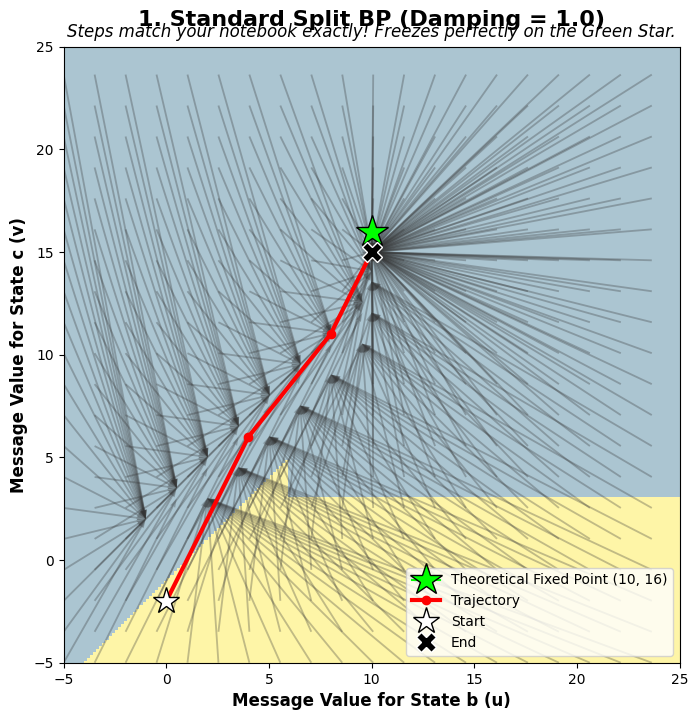

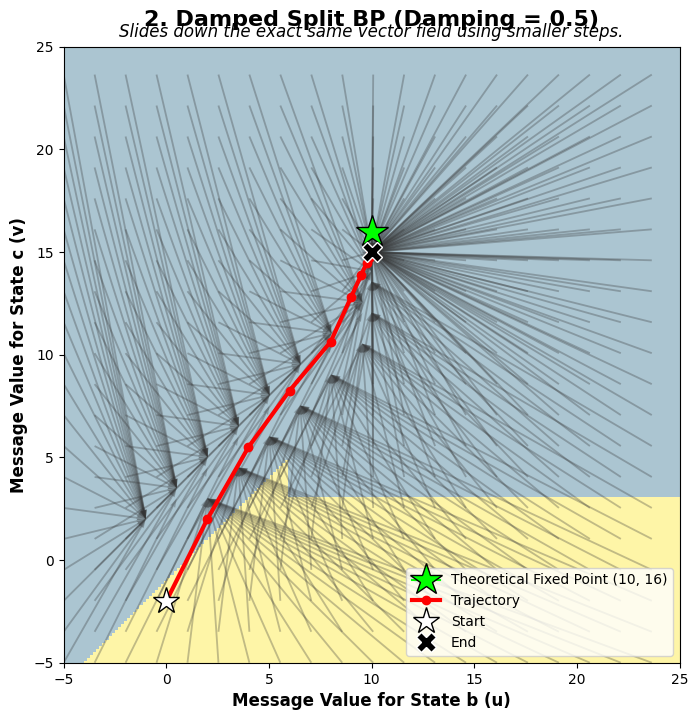

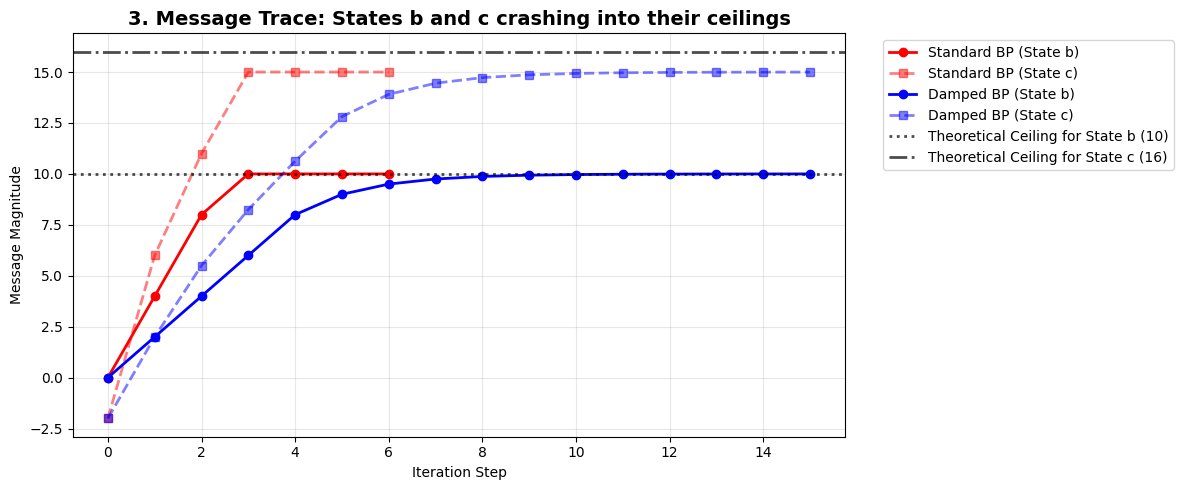

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==========================================
# 1. THE DYNAMICS ENGINE (Corrected Physics)
# ==========================================

class DynamicsEngine:
    def __init__(self, matrix):
        self.C = np.array(matrix)

    def get_geometry(self, u, v):
        """
        Calculates Vector Field (du, dv) and Saturation Regions.
        Simulates the FULL 2-Hop closed loop (Left -> Right -> Left).
        u = State b, v = State c. (State a is anchored to 0).
        """
        # A. Scalar Input (For Simulation Loop)
        if np.isscalar(u):
            # Anchor state 'a' to 0
            q_left = np.array([0.0, float(u), float(v)])
            
            # Forward Pass (Bottom Factor: Left -> Right, min over rows)
            cost_bot = self.C + q_left[:, None]
            msg_right = np.min(cost_bot, axis=0)
            
            # Backward Pass (Top Factor: Right -> Left, min over cols)
            cost_top = self.C + msg_right[None, :]
            msg_left = np.min(cost_top, axis=1)
            
            # Target relative to state 'a'
            target_u = msg_left[1] - msg_left[0]
            target_v = msg_left[2] - msg_left[0]
            
            # Vector Field is the step DIFFERENCE (Target - Current)
            du = target_u - u
            dv = target_v - v
            return du, dv

        # B. Grid Input (For Visualization Map)
        else:
            zeros = np.zeros_like(u)
            q_left = np.stack([zeros, u, v], axis=0)
            
            # Forward Pass Broadcast
            cost_bot = self.C[:, :, None, None] + q_left[:, None, :, :]
            msg_right = np.min(cost_bot, axis=0)
            
            # Backward Pass Broadcast
            cost_top = self.C[:, :, None, None] + msg_right[None, :, :, :]
            msg_left = np.min(cost_top, axis=1)
            
            # Targets
            target_U = msg_left[1] - msg_left[0]
            target_V = msg_left[2] - msg_left[0]
            
            # Vector field
            DU = target_U - u
            DV = target_V - v
            
            # Region Classification: How many distinct columns won in the Top factor?
            # 1=Purple (Full Saturation), 2=Teal (State Elimination), 3=Yellow (Linear Core)
            winners = np.argmin(cost_top, axis=1)
            w_sort = np.sort(winners, axis=0)
            diffs = np.diff(w_sort, axis=0) != 0
            Regions = np.sum(diffs, axis=0) + 1
            return DU, DV, Regions

    def simulate(self, start, steps, damping=1.0):
        """
        Simulates the trajectory using Split (Parallel) updates.
        """
        path = [np.array(start, dtype=float)]
        curr = np.array(start, dtype=float)
        
        for _ in range(steps):
            # Calculate gradient based on OLD position
            du, dv = self.get_geometry(curr[0], curr[1])
            
            # Update position (Add the gradient * damping)
            curr[0] += du * damping
            curr[1] += dv * damping
            
            path.append(curr.copy())
            
        return np.array(path)

# ==========================================
# 2. VISUALIZATION (Dynamic Zoom & Fixes)
# ==========================================

def plot_scenario(engine, path, title, subtitle):
    """
    Plots a single scenario in its own figure.
    Dynamically resizes the background map to fit the trajectory.
    """
    max_val = np.max(np.abs(path))
    limit = max(25.0, float(max_val) * 1.2) 
    
    # Start grid slightly below zero so origin is clearly visible
    res = 200
    u = np.linspace(-5, limit, res)
    v = np.linspace(-5, limit, res)
    U, V = np.meshgrid(u, v)
    DU, DV, Regions = engine.get_geometry(U, V)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Custom Colormap: Purple, Teal, Yellow
    # vmin=1, vmax=3 strictly locks the colors to the 3 phases!
    cmap = mcolors.ListedColormap(['#481567', '#2D708E', '#FDE725'])
    ax.pcolormesh(U, V, Regions, cmap=cmap, shading='auto', alpha=0.4, vmin=1, vmax=3)
    
    # Vector Field (Arrows) - Physically accurate arrows!
    step = int(res / 20)
    ax.quiver(U[::step,::step], V[::step,::step], 
              DU[::step,::step], DV[::step,::step], 
              angles='xy', scale_units='xy', scale=1, alpha=0.3, color='#333')

    # Draw Theoretical Fixed Point
    ax.plot(10, 16, marker='*', color='#00FF00', markersize=24, 
            markeredgecolor='black', zorder=5, label='Theoretical Fixed Point (10, 16)')

    # Trajectory
    ax.plot(path[:,0], path[:,1], 'r-o', linewidth=3, zorder=6, label='Trajectory')
    ax.plot(path[0,0], path[0,1], 'w*', markersize=20, markeredgecolor='k', zorder=7, label='Start')
    ax.plot(path[-1,0], path[-1,1], 'X', markersize=15, color='black', markeredgecolor='white', zorder=7, label='End')

    # Styling
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.text((limit-5)/2, limit + (limit * 0.02), subtitle, ha='center', fontsize=12, 
            style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    ax.set_xlabel("Message Value for State b (u)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Message Value for State c (v)", fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xlim(-5, limit)
    ax.set_ylim(-5, limit)
    ax.legend(loc='lower right')
    
    plt.show()

def plot_traces(paths, labels, title):
    """
    Plots the message value traces side-by-side with analytical ceilings.
    """
    plt.figure(figsize=(12, 5))
    colors = ['red', 'blue']
    for i, path in enumerate(paths):
        # State b (u)
        plt.plot(path[:, 0], marker='o', linestyle='-', linewidth=2, color=colors[i], label=f"{labels[i]} (State b)")
        # State c (v)
        plt.plot(path[:, 1], marker='s', linestyle='--', linewidth=2, color=colors[i], alpha=0.5, label=f"{labels[i]} (State c)")
    
    # Theoretical Brick Walls calculated via 2-Hop Thresholds
    plt.axhline(10, color='black', linestyle=':', linewidth=2, alpha=0.7, label="Theoretical Ceiling for State b (10)")
    plt.axhline(16, color='black', linestyle='-.', linewidth=2, alpha=0.7, label="Theoretical Ceiling for State c (16)")
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Iteration Step")
    plt.ylabel("Message Magnitude")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. SETUP & RUN
# ==========================================

# A. Define Matrix (Matching the hand trace exactly!)
MATRIX = [
    [0,  10, 20],
    [10, 2,  5],
    [20, 6,  4]
]
engine = DynamicsEngine(MATRIX)
start_point = [0, -2] 

# B. Run Scenarios
# 1. Standard BP (Damping 1.0) - Reaches the fixed point perfectly in 4 steps!
path_std = engine.simulate(start_point, steps=6, damping=1.0)

# 2. Damped BP (Damping 0.5) - Slides down slowly
path_dmp = engine.simulate(start_point, steps=15, damping=0.5)

# ==========================================
# 4. OUTPUT
# ==========================================

# FIGURE 1: STANDARD BP
plot_scenario(engine, path_std, 
              title="1. Standard Split BP (Damping = 1.0)", 
              subtitle="Steps match your notebook exactly! Freezes perfectly on the Green Star.")

# FIGURE 2: DAMPED BP
plot_scenario(engine, path_dmp, 
              title="2. Damped Split BP (Damping = 0.5)", 
              subtitle="Slides down the exact same vector field using smaller steps.")

# FIGURE 3: TRACES
plot_traces([path_std, path_dmp], 
            ["Standard BP", "Damped BP"], 
            "3. Message Trace: States b and c crashing into their ceilings")

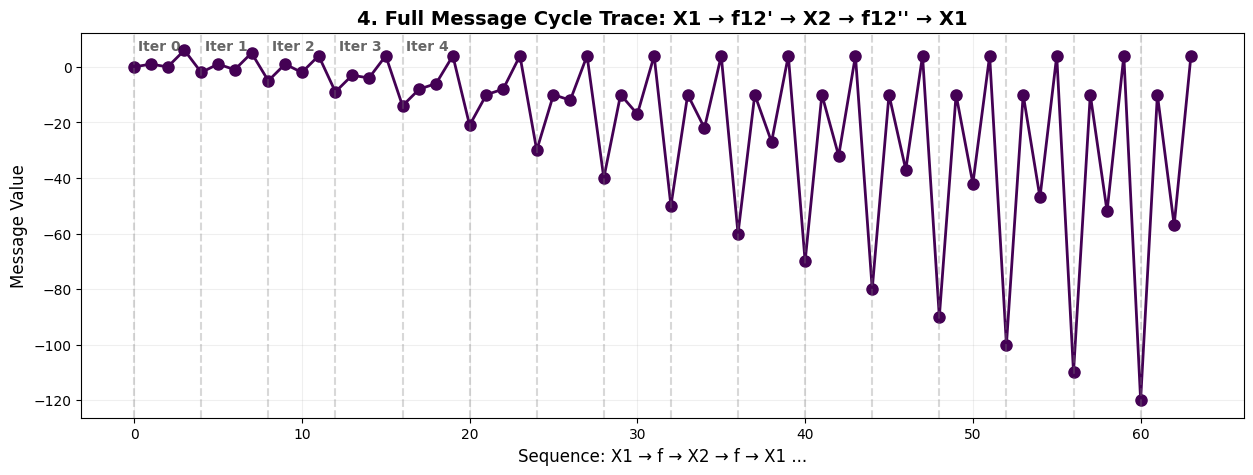

In [4]:
def plot_bipartite_traces(engine, path, title):
    """
    Visualizes the message sequence flowing around the loop:
    X1 -> f12' -> X2 -> f12'' -> X1
    """
    traces = []
    C = engine.C
    
    for i in range(len(path)):
        u, v = path[i]
        
        # 1. Message X1 -> f: Value of 'u'
        m1 = u
        
        # 2. Message f -> X2: Result of marginalizing over u
        q_u = np.array([u, 1000, 0])
        tc_u = C + q_u[:, None]
        mins_u = np.min(tc_u, axis=0)
        m2 = mins_u[1] - mins_u[2]
        
        # 3. Message X2 -> f: Value of 'v'
        m3 = v
        
        # 4. Message f -> X1: Result of marginalizing over v
        q_v = np.array([1000, v, 0])
        tc_v = C + q_v[:, None]
        mins_v = np.min(tc_v, axis=0)
        m4 = mins_v[0] - mins_v[2]
        
        traces.extend([m1, m2, m3, m4])
        
    plt.figure(figsize=(15, 5))
    plt.plot(traces, marker='o', linestyle='-', color='#440154', linewidth=2, markersize=8)
    
    for k in range(len(path)):
        plt.axvline(k*4, color='gray', linestyle='--', alpha=0.3)
        if k < 5:
            plt.text(k*4 + 1.5, max(traces), f"Iter {k}", ha='center', fontweight='bold', alpha=0.6)
            
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Sequence: X1 → f → X2 → f → X1 ...", fontsize=12)
    plt.ylabel("Message Value", fontsize=12)
    plt.grid(True, alpha=0.2)
    plt.show()

# Generate the Trace for the Damped (Convergent) Scenario
plot_bipartite_traces(engine, path_dmp, "4. Full Message Cycle Trace: X1 → f12' → X2 → f12'' → X1")
